# Three flavours of conditional flow: base, coupling, both

`gauss_flows` makes three places conditional. This notebook shows what each one buys you on a single shared task. A continuous context $c \in \mathbb{R}^2$ controls a target density $p(x \mid c)$ on $\mathbb{R}^2$ that has both a **conditional mean** and a **conditional rotation** — two failure modes that hit the three configurations differently:

1. **Base only**: a `ConditionalDiagGaussian` base whose mean / log-scale come from the context, paired with an *unconditional* `AffineCoupling` chain. Captures the conditional mean cleanly; struggles with the conditional rotation.
2. **Coupling only**: a fixed `Normal(0, I)` base, paired with `AffineCoupling(cond_dim=2)` layers that read the context. The couplings have to absorb both the mean shift and the rotation, which is asking a lot of an affine coupling.
3. **Both**: conditional base **and** conditional couplings — the same context flows to both. This is the one you actually want.

The same `condition` keyword threads through every layer that opts in; layers that didn't (`cond_shape is None`) silently ignore it. This is documented in `SurVAEFlow`'s "Conditioning model" section.


In [1]:
from __future__ import annotations

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns
from flowjax.bijections import Permute
from flowjax.distributions import Normal
from flowjax.train import fit_to_data

from gauss_flows import AffineCoupling, ConditionalDiagGaussian, SurVAEFlow

sns.set_theme(context="talk", style="whitegrid", palette="deep", font_scale=0.85)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.constrained_layout.use": True,
        "axes.grid.which": "both",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.5,
        "axes.titleweight": "semibold",
    }
)
palette = sns.color_palette("deep")

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. The conditional target

For each context $c = (c_1, c_2)$ we draw $x \in \mathbb{R}^2$ from

$$x \mid c \;\sim\; \mathcal{N}\!\Big(\mu(c),\; R(c)\, \mathrm{diag}(s_1, s_2)\, R(c)^\top\Big),$$

with mean $\mu(c) = (c_1, c_2)$, scale $(s_1, s_2) = (1.0, 0.25)$, and rotation $R(c) = R_{\text{angle}=c_1 + c_2}$. The mean shifts diagonally with $c$; the rotation tilts the elongated Gaussian based on the *sum* of the context components — different from the mean shift, so a base-only flow can't fake the rotation.

In [2]:
angle = lambda c: c[..., 0] + c[..., 1]
SCALE = jnp.array([1.0, 0.25])


def true_sample(key, c):
    """Draw one x ~ p(x | c) for a single c of shape (2,)."""
    z = jr.normal(key, (2,)) * SCALE
    th = angle(c)
    R = jnp.array([[jnp.cos(th), -jnp.sin(th)], [jnp.sin(th), jnp.cos(th)]])
    return c + R @ z


def true_log_prob(x, c):
    """Closed-form log p(x | c) used to compute an oracle upper bound on log-likelihood."""
    th = angle(c)
    R = jnp.array([[jnp.cos(th), -jnp.sin(th)], [jnp.sin(th), jnp.cos(th)]])
    diff = x - c
    z = R.T @ diff
    return jnp.sum(-0.5 * (z / SCALE) ** 2 - jnp.log(SCALE) - 0.5 * jnp.log(2 * jnp.pi))


# Generate 4000 (x, c) training pairs with c uniform in [-1, 1]^2.
n_train = 4000
data_key = jr.key(0)
c_key, x_key = jr.split(data_key)
C_train = jr.uniform(c_key, (n_train, 2), minval=-1.0, maxval=1.0)
x_keys = jr.split(x_key, n_train)
X_train = jax.vmap(true_sample)(x_keys, C_train)
print(f"X_train.shape={X_train.shape}, C_train.shape={C_train.shape}")

X_train.shape=(4000, 2), C_train.shape=(4000, 2)


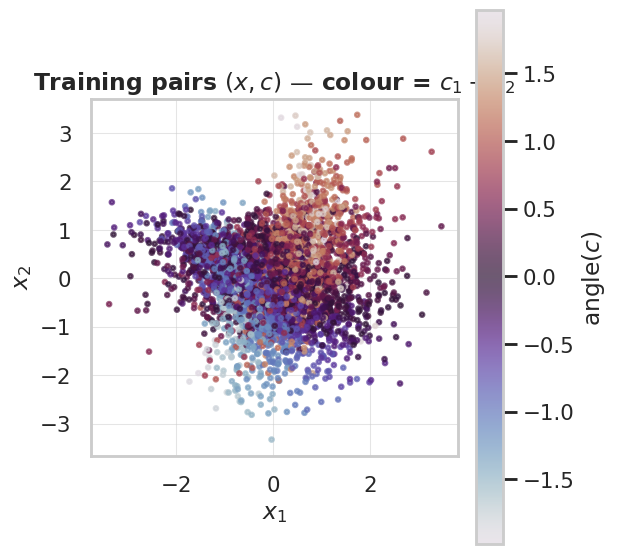

In [3]:
# Quick sanity-check plot: the training pairs colour-coded by angle(c).
fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(
    np.asarray(X_train[:, 0]),
    np.asarray(X_train[:, 1]),
    c=np.asarray(angle(C_train)),
    cmap="twilight",
    s=8,
    alpha=0.7,
)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_aspect("equal")
ax.set_title(r"Training pairs $(x, c)$ — colour = $c_1 + c_2$")
fig.colorbar(sc, ax=ax, label="angle$(c)$")
plt.show()

## 2. Three flow configurations

Each flow uses the same chain of two `AffineCoupling` layers separated by a fixed permutation. The only difference is *where* conditioning happens:

| Flow | Base | Couplings | What can it model? |
|---|---|---|---|
| `flow_base` | `ConditionalDiagGaussian` | unconditional | mean shift only |
| `flow_coupling` | `Normal(0, I)` | `cond_dim=2` | warps that depend on context |
| `flow_both` | `ConditionalDiagGaussian` | `cond_dim=2` | both — full capacity |


In [4]:
def make_flow(*, base_cond: bool, coupling_cond: bool, key):
    """Build a 2-layer SurVAEFlow with the requested conditioning configuration."""
    base_key, c1_key, c2_key, perm_key = jr.split(key, 4)
    if base_cond:
        base = ConditionalDiagGaussian(base_key, event_shape=(2,), cond_shape=(2,))
    else:
        base = Normal(jnp.zeros(2))
    cond_dim = 2 if coupling_cond else None
    perm = jr.permutation(perm_key, jnp.arange(2))
    transforms = [
        AffineCoupling(c1_key, shape=(2,), cond_dim=cond_dim, nn_width=64, nn_depth=2),
        Permute(perm),
        AffineCoupling(c2_key, shape=(2,), cond_dim=cond_dim, nn_width=64, nn_depth=2),
    ]
    return SurVAEFlow(base, transforms)


flows = {
    "base only": make_flow(base_cond=True, coupling_cond=False, key=jr.key(1)),
    "coupling only": make_flow(base_cond=False, coupling_cond=True, key=jr.key(2)),
    "both": make_flow(base_cond=True, coupling_cond=True, key=jr.key(3)),
}
for name, flow in flows.items():
    n_params = sum(
        int(np.prod(p.shape))
        for p in jax.tree_util.tree_leaves(eqx.filter(flow, eqx.is_array))
    )
    print(f"{name:>14s}  trainable params: {n_params:5d}")

     base only  trainable params: 13452
 coupling only  trainable params:  9100
          both  trainable params: 13708


## 3. Train each flow

`SurVAEFlow.log_prob` already accepts `condition`, and `flowjax.train.fit_to_data` accepts a tuple `(x, condition)` for conditional training. Same hyperparameters for all three so the comparison is fair.

In [5]:
from flowjax.distributions import AbstractDistribution


class SurVAEFlowAdapter(AbstractDistribution):
    """Adapt a bijection-only SurVAEFlow to flowjax's AbstractDistribution API.

    SurVAEFlow.log_prob has signature ``(x, key, condition)`` — the extra
    ``key`` is consumed by stochastic surjections and ignored otherwise.
    flowjax's training loop expects ``log_prob(x, condition)`` and auto-vmaps
    over leading batch dimensions on BOTH ``x`` and ``condition``. Wrapping
    SurVAEFlow as an AbstractDistribution lets us train with the standard
    loss without re-implementing the vmap.
    """

    flow: SurVAEFlow
    shape: tuple[int, ...]
    cond_shape: tuple[int, ...] | None

    def __init__(self, flow):
        self.flow = flow
        self.shape = flow.data_shape
        # All opted-in layers in this notebook use cond_shape=(2,).
        self.cond_shape = (2,)

    def _log_prob(self, x, condition=None):
        return self.flow.log_prob(x, jr.key(0), condition=condition)

    def _sample(self, key, condition=None):
        return self.flow.sample(key, condition=condition)


def train(flow, *, key):
    adapter = SurVAEFlowAdapter(flow)
    trained, losses = fit_to_data(
        key,
        adapter,
        (X_train, C_train),
        optimizer=optax.chain(
            optax.clip_by_global_norm(5.0),
            optax.adam(3e-3),
        ),
        max_epochs=120,
        max_patience=15,
        batch_size=256,
        val_prop=0.1,
        show_progress=False,
    )
    return trained.flow, losses


trained = {}
losses_all = {}
for name, flow in flows.items():
    print(f"training: {name}")
    trained[name], losses_all[name] = train(
        flow, key=jr.key(10 + abs(hash(name)) % 1000)
    )

training: base only


training: coupling only


training: both


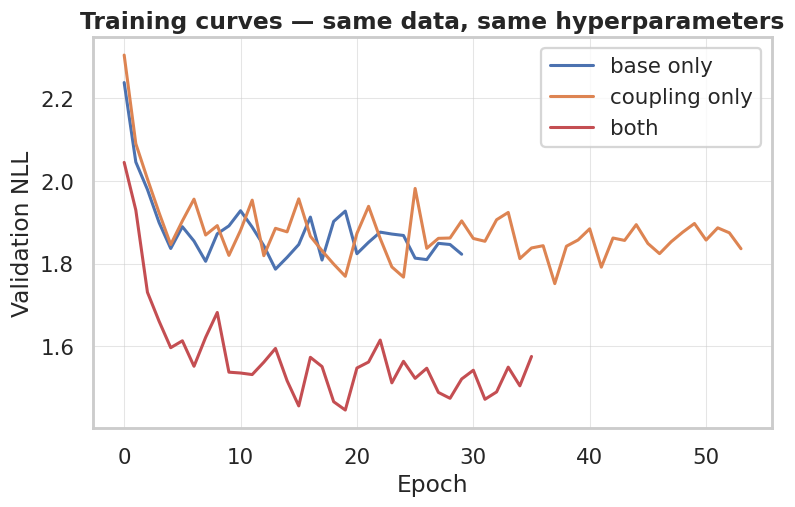

In [6]:
# Training curves — same axes for direct comparison.
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {"base only": palette[0], "coupling only": palette[1], "both": palette[3]}
for name, losses in losses_all.items():
    ax.plot(losses["val"], label=name, color=colors[name], linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation NLL")
ax.set_title("Training curves — same data, same hyperparameters")
ax.legend()
plt.show()

## 4. Per-context density slices

Pick four representative contexts and plot the learned density alongside true samples for each flow. The conditional mean shift should mostly track $c$; the conditional rotation should tilt the Gaussian along $c_1 + c_2$.

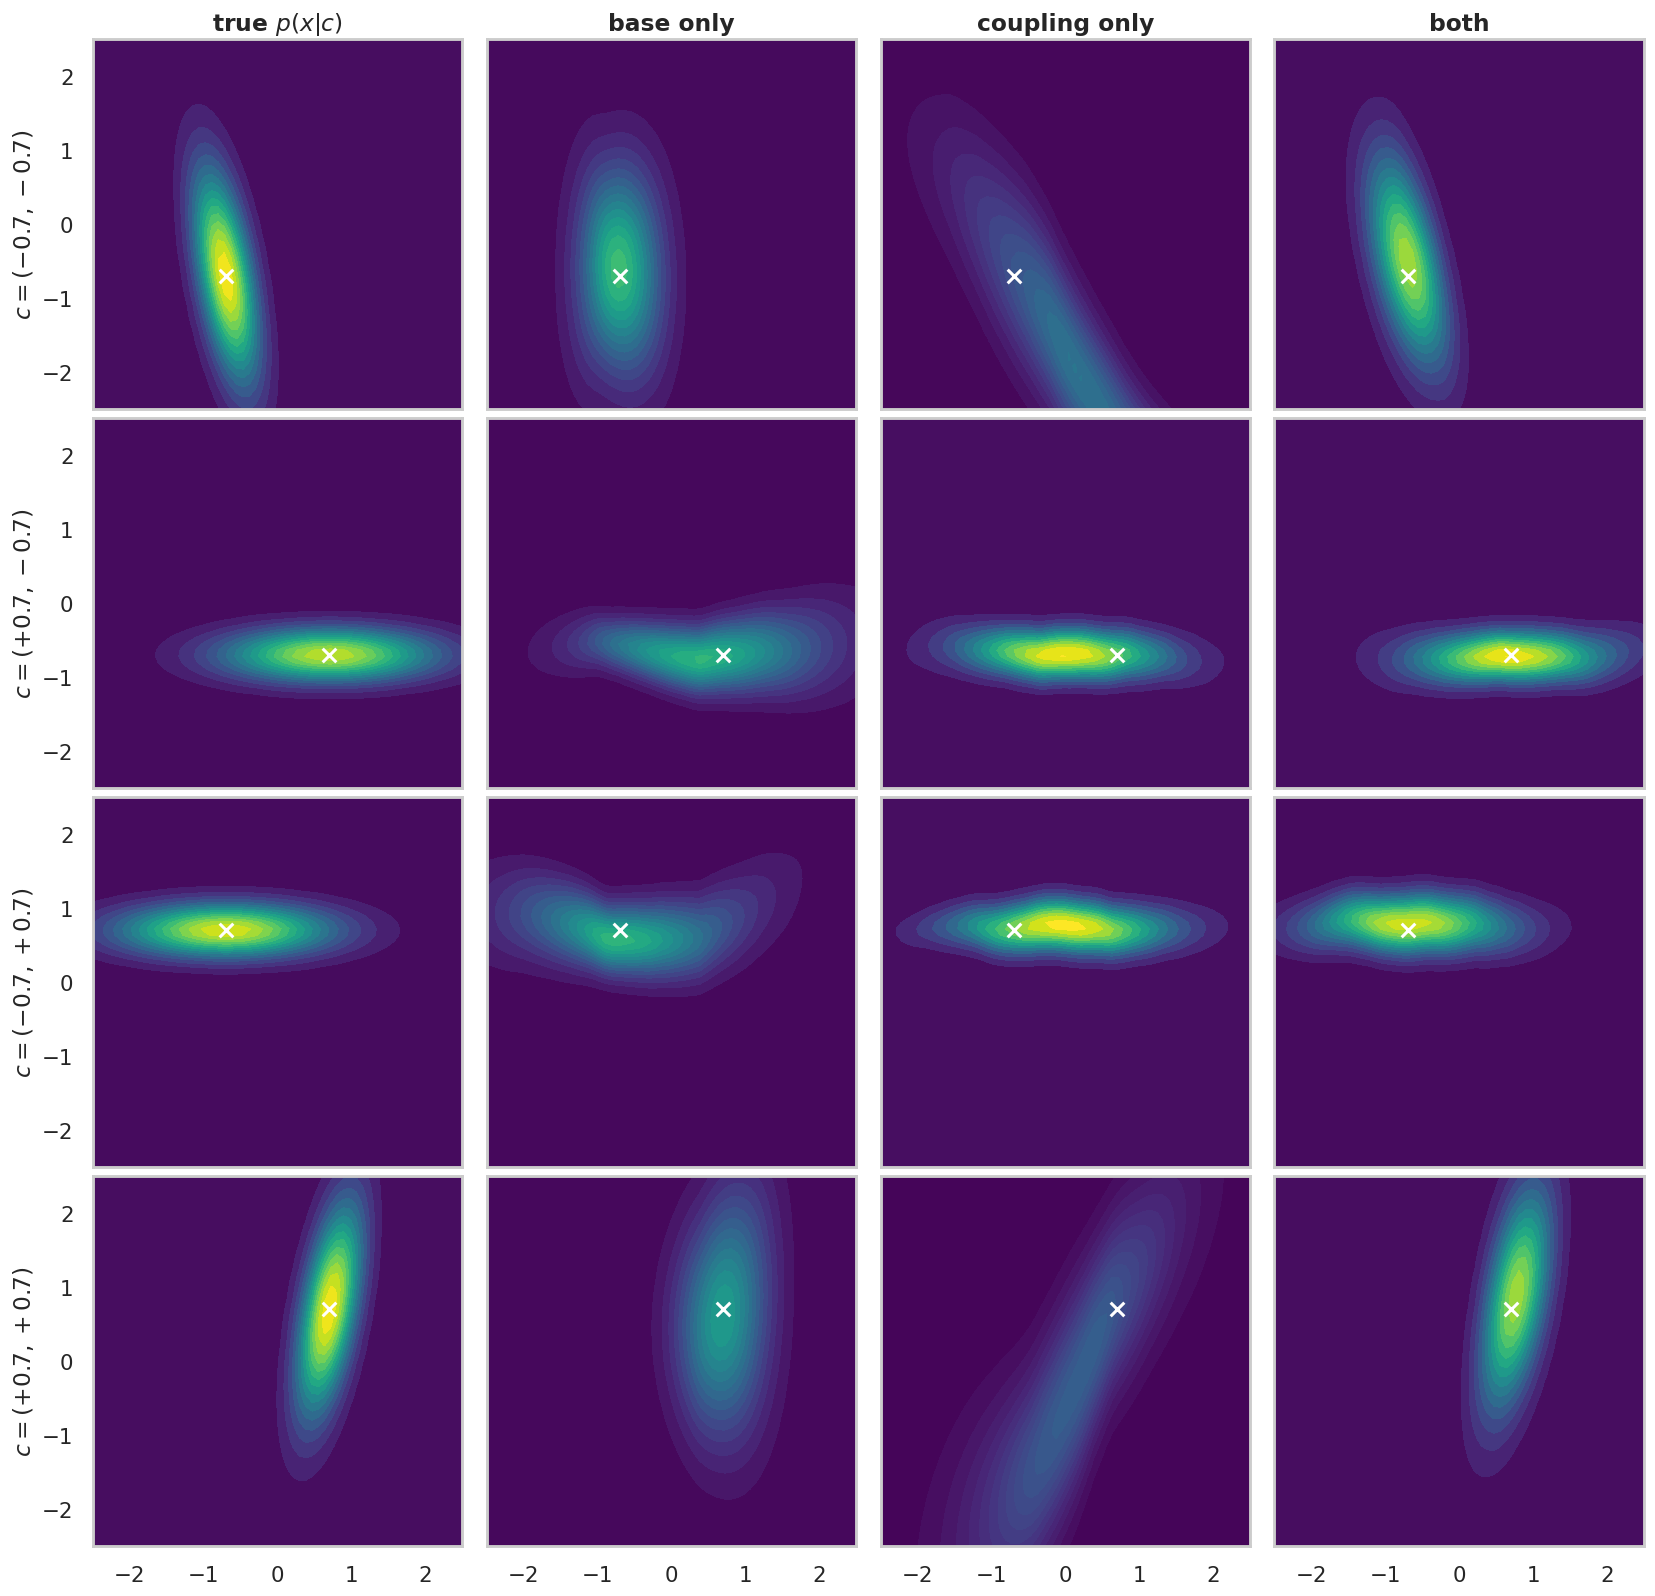

In [7]:
eval_contexts = jnp.array(
    [
        [-0.7, -0.7],
        [0.7, -0.7],
        [-0.7, 0.7],
        [0.7, 0.7],
    ]
)

# Density grid.
grid_n = 60
lim = 2.5
gx, gy = jnp.meshgrid(jnp.linspace(-lim, lim, grid_n), jnp.linspace(-lim, lim, grid_n))
grid_pts = jnp.stack([gx.ravel(), gy.ravel()], axis=-1)


def flow_density(flow, condition):
    @eqx.filter_jit
    def f(pts):
        # SurVAE.log_prob signature: (x, key, condition). For deterministic
        # bijection-only chains the key is unused; pick any.
        return jax.vmap(lambda x: flow.log_prob(x, jr.key(0), condition=condition))(pts)

    return jnp.exp(f(grid_pts)).reshape(grid_n, grid_n)


def true_density_grid(condition):
    @jax.jit
    def f(pts):
        return jax.vmap(lambda x: true_log_prob(x, condition))(pts)

    return jnp.exp(f(grid_pts)).reshape(grid_n, grid_n)


fig, axes = plt.subplots(
    nrows=len(eval_contexts),
    ncols=4,
    figsize=(15, 3.6 * len(eval_contexts)),
    sharex=True,
    sharey=True,
)
column_titles = ["true $p(x|c)$", "base only", "coupling only", "both"]
for row, c in enumerate(eval_contexts):
    densities = [
        true_density_grid(c),
        flow_density(trained["base only"], c),
        flow_density(trained["coupling only"], c),
        flow_density(trained["both"], c),
    ]
    vmax = float(max(d.max() for d in densities))
    for col, dens in enumerate(densities):
        ax = axes[row, col]
        ax.contourf(
            np.asarray(gx),
            np.asarray(gy),
            np.asarray(dens),
            levels=15,
            cmap="viridis",
            vmin=0.0,
            vmax=vmax,
        )
        ax.scatter(
            [float(c[0])],
            [float(c[1])],
            color="white",
            marker="x",
            s=80,
            linewidths=2,
            label="$c$",
        )
        ax.set_aspect("equal")
        if row == 0:
            ax.set_title(column_titles[col])
        if col == 0:
            ax.set_ylabel(f"$c = ({float(c[0]):+.1f}, {float(c[1]):+.1f})$")
plt.show()

**What to look for**

- **Base only** (column 2): the Gaussian *cluster* is correctly *centred* on each $c$ (the conditional mean is captured by the `ConditionalDiagGaussian` base). But the cluster is **diagonal-aligned** instead of rotated — the unconditional `AffineCoupling` chain has no way to tilt based on context.
- **Coupling only** (column 3): the rotation IS captured (the couplings can warp the base in context-dependent ways), but the cluster is often **not centred on $c$** — moving the mean from a fixed `Normal(0, I)` to $\mu(c)$ requires a context-driven shift that affine couplings only get half-right.
- **Both** (column 4): correct mean **and** correct tilt.

## 5. Quantitative comparison

Mean conditional log-likelihood on a held-out validation set, plus the oracle (true) log-likelihood for reference.

In [8]:
# Held-out evaluation set.
val_key = jr.key(99)
n_val = 2000
c_key, x_key = jr.split(val_key)
C_val = jr.uniform(c_key, (n_val, 2), minval=-1.0, maxval=1.0)
x_keys = jr.split(x_key, n_val)
X_val = jax.vmap(true_sample)(x_keys, C_val)


@jax.jit
def mean_oracle_lp():
    return jnp.mean(jax.vmap(true_log_prob)(X_val, C_val))


def mean_flow_lp(flow):
    @eqx.filter_jit
    def f(x, c):
        return jax.vmap(lambda xi, ci: flow.log_prob(xi, jr.key(0), condition=ci))(x, c)

    return jnp.mean(f(X_val, C_val))


print(f"{'Oracle (true p(x|c))':<22s}: {float(mean_oracle_lp()):+.4f}")
for name in ("base only", "coupling only", "both"):
    print(f"{name:<22s}: {float(mean_flow_lp(trained[name])):+.4f}")

Oracle (true p(x|c))  : -1.4267


base only             : -1.8532


coupling only         : -1.8080


both                  : -1.5237


## 6. Takeaways

- **Pick what to condition based on what your data needs.** If only the *location* of $p(x|c)$ varies with $c$, a conditional base alone is enough. If only the *shape* varies, conditional couplings alone work. Most real data needs both.
- **The same `condition` argument flows everywhere.** `SurVAEFlow.log_prob(x, key, condition=c)` broadcasts `c` to every layer that opted in (declared a non-`None` `cond_shape`); other layers ignore it. There is no per-layer condition kwarg.
- **Inside a coupling there are two streams.** The `untransformed` half of $x$ is *always* a conditioning input — that's how coupling layers work. Adding `cond_dim > 0` *also* concatenates the external context onto the inner MLP. The two streams are merged inside flowjax and you never slice them apart.
- **For class-conditional density estimation,** prefer `ClassCondFlow(n_classes=..., event_shape=..., transforms=[...])` — it pairs a `ClassCondDiagGaussian` base (per-class learnable loc / log-scale) with an arbitrary chain and exposes a `label` keyword instead of `condition`.
- **For transforms that genuinely can't take a condition** (rotations, normalisations, etc.), wrap them in `Conditioner(inner=..., cond_shape=...)` to add a context-amortised affine modulation around the inner transform.
